# 06 — Train and evaluate XGBoost

This notebook uses the verified CB2 modeling preparation handoff to train one XGBoost regressor for each frozen split protocol. It follows the random forest notebook's sequence: fit a fixed baseline, predict training and validation pKi, calculate the same MAE/RMSE/R² and similarity subgroups, plot the same diagnostics, save and verify, then run a bounded training-only hyperparameter search and compare validation results. Protocol-specific test structures remain reserved.

XGBoost adds trees sequentially. The fixed baseline and the selected search model are saved together in one accepted run, with separate manifests for the baseline and tuning stages.

**Reference:** All source and supporting files are in [provenance](../provenance/README.md). The data provenance [Excel workbook](../provenance/CB2_data_provenance.xlsx) is generated from the current data and refreshed by each notebook's final cell. Saved outputs below describe the previous execution; printed old paths can differ. Rerun notebooks 00–09 in order to refresh the complete pipeline.

**XGBoost reference:** [summary.xlsx](../provenance/models/xgboost/summary.xlsx) combines baseline and tuned results. Supporting evidence is in `files/baseline/`, `files/tuning/`, and `files/diagnostics/`. A successful complete execution replaces both variants and regenerates the workbook.


## 1. Verify the completed preparation handoff

Use the same completed preparation manifest and fingerprint bits as the forest and dummy notebooks. Check the source file hashes and software versions before fitting; XGBoost's installed version is recorded separately in this run's manifest.


In [1]:
from pathlib import Path
import sys
# Shared storage helpers keep the notebooks on the same completed dataset.
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "scripts"))
from provenance_support import (
    latest_acquisition, current_selection, current_curation, current_preparation,
    current_mlp_baseline, save_review_record, load_review_record,
)
from datetime import datetime, timezone
from time import perf_counter
import hashlib
import json
import platform

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit
import sklearn
import xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PREP_MANIFEST_REL = current_preparation(project_root)
XGBOOST_NAMES = {"random": "random_xgboost", "scaffold": "scaffold_xgboost"}
SUBSETS = ("train", "validation", "test")
run_started_at_utc = datetime.now(timezone.utc).isoformat()
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
assert (project_root / "notebooks/03_modeling_preparation.ipynb").is_file()

def sha256_file(path):
    """Read bytes in chunks to verify recorded source and output files."""
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def json_safe_parameters(model):
    """Represent XGBoost's NaN missing marker as readable, valid JSON."""
    return {
        name: "NaN (XGBoost missing-value marker)" if isinstance(value, (float, np.floating))
        and np.isnan(value) else value
        for name, value in model.get_params().items()
    }

# The named run must be complete and must have passed every recorded preparation check.
prep_manifest_path = project_root / PREP_MANIFEST_REL
assert prep_manifest_path.is_file(), f"Preparation manifest is missing: {prep_manifest_path}"
with prep_manifest_path.open(encoding="utf-8") as stream:
    prep_manifest = json.load(stream)
assert prep_manifest.get("completed_at_utc") and prep_manifest.get("stage") == "modeling_preparation"
required_checks = (
    "source_hashes", "saved_arrays_and_fingerprint_bits", "saved_splits_and_scaffolds",
    "saved_audit_reports",
)
for check in required_checks:
    assert prep_manifest.get("verification", {}).get(check) is True, check
assert prep_manifest.get("models_fitted") is False
prep_folder_rel = Path(prep_manifest["output_folder"])
assert (project_root / prep_folder_rel).resolve() == prep_manifest_path.parent.resolve()
required_filenames = (
    "fingerprints_and_targets.npz", "split_assignments.csv", "heldout_training_neighbors.csv",
)
artifact_paths = {}
for filename in required_filenames:
    relative_name = (prep_folder_rel / filename).as_posix()
    assert relative_name in prep_manifest["artifact_sha256"], filename
    artifact_path = project_root / relative_name
    assert artifact_path.is_file(), f"Preparation artifact is missing: {relative_name}"
    assert sha256_file(artifact_path) == prep_manifest["artifact_sha256"][relative_name], relative_name
    artifact_paths[filename] = artifact_path
source_manifest_hash = sha256_file(prep_manifest_path)

# Exact package versions avoid changing fingerprint interpretation or estimator behavior silently.
# The operating system is recorded too: tree libraries can resolve near-tied splits
# differently on Windows and Linux, so results are only exactly comparable on one OS.
installed_versions = {
    "python": platform.python_version(), "platform": platform.system(), "rdkit": rdkit.__version__,
    "numpy": np.__version__, "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__, "joblib": joblib.__version__, "xgboost": xgboost.__version__,
}
version_differences = {
    package: (saved, installed_versions.get(package))
    for package, saved in prep_manifest["software_versions"].items()
    if installed_versions.get(package) != saved
}
assert not version_differences, f"Preparation/current software versions differ: {version_differences}"
print(f"{'Preparation run':<27} | {PREP_MANIFEST_REL.as_posix()}")
print(f"{'Verified input artifacts':<27} | {len(artifact_paths):>7,}")
print(f"{'scikit-learn version':<27} | {sklearn.__version__}")

Preparation run             | provenance/preparation/manifest.json
Verified input artifacts    |       3
scikit-learn version        | 1.9.0


## 2. Align saved rows with both split protocols

Match split assignments to fingerprint-array rows by structure key. The random and scaffold protocols each keep their own training, validation, and reserved test subsets. No scaling or new feature selection is introduced for this model.


In [2]:
# NPZ loading disallows pickled objects and preserves the preparation row order.
with np.load(artifact_paths["fingerprints_and_targets.npz"], allow_pickle=False) as saved:
    X = saved["X"]
    y = saved["y"]
    structure_keys = saved["rdkit_smiles"]
feature_width = int(prep_manifest["configuration"]["fingerprint"]["bits"])
assert X.ndim == 2 and X.shape[1] == feature_width
assert X.dtype == np.uint8 and np.isin(X, (0, 1)).all()
assert y.ndim == 1 and len(X) == len(y) == len(structure_keys)
assert np.isfinite(y).all() and structure_keys.dtype.kind == "U"
assert len(set(structure_keys)) == len(structure_keys) == prep_manifest["counts"]["structures"]

# Map saved labels through structure keys rather than relying on CSV row position.
assignments = pd.read_csv(artifact_paths["split_assignments.csv"], dtype=str, keep_default_na=False)
assert list(assignments.columns) == [
    "split_strategy", "rdkit_smiles", "subset", "scaffold", "fingerprint_group_id"
]
assert len(assignments) == len(structure_keys) * len(XGBOOST_NAMES)
assert not assignments.duplicated(["split_strategy", "rdkit_smiles"]).any()
assert set(assignments["split_strategy"]) == set(XGBOOST_NAMES)
assert set(assignments["subset"]) == set(SUBSETS)
split_indices = {}
for strategy in XGBOOST_NAMES:
    rows = assignments.loc[assignments["split_strategy"].eq(strategy)]
    assert set(rows["rdkit_smiles"]) == set(structure_keys)
    subset_by_key = dict(zip(rows["rdkit_smiles"], rows["subset"]))
    labels = np.asarray([subset_by_key[key] for key in structure_keys])
    split_indices[strategy] = {}
    for subset in SUBSETS:
        indices = np.flatnonzero(labels == subset)
        expected = prep_manifest["counts"]["split_subsets"][strategy][subset]["structures"]
        assert len(indices) == expected and len(indices) > 0
        assert set(structure_keys[indices]) == set(rows.loc[rows["subset"].eq(subset), "rdkit_smiles"])
        split_indices[strategy][subset] = indices
    assert set(split_indices[strategy]["train"]).isdisjoint(split_indices[strategy]["validation"])
    assert set(split_indices[strategy]["train"]).isdisjoint(split_indices[strategy]["test"])
    assert set(split_indices[strategy]["validation"]).isdisjoint(split_indices[strategy]["test"])
    print(f"{strategy:<10} | train {len(split_indices[strategy]['train']):>5,} | "
          f"validation {len(split_indices[strategy]['validation']):>4,} | "
          f"reserved test {len(split_indices[strategy]['test']):>4,}")

random     | train 2,860 | validation  358 | reserved test  358
scaffold   | train 2,778 | validation  461 | reserved test  337


## 3. Fit one fixed XGBoost baseline per protocol

Both regressors use the same declared starting settings and train only on their own protocol's training rows. XGBoost builds trees sequentially to correct prior errors. No validation or test labels enter fitting or early stopping; the number of boosting rounds is fixed here.


In [3]:
# Fixed initial XGBoost configuration; the search below starts only after the baseline is saved.
# A boosting round adds a tree to correct errors made by the previous trees.
xgb_parameters = {
    "objective": "reg:squarederror",
    "n_estimators": 250,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "min_child_weight": 2,
    "reg_lambda": 1,
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": 4,
}

boosters = {}
training_rows = []
training_slices = {}
for strategy, model_name in XGBOOST_NAMES.items():
    train_indices = split_indices[strategy]["train"]
    assert len(X[train_indices]) == len(y[train_indices])
    training_slices[strategy] = train_indices[:5]
    started = perf_counter()
    model = XGBRegressor(**xgb_parameters)
    model.fit(X[train_indices], y[train_indices])
    fit_seconds = perf_counter() - started
    assert model.n_features_in_ == feature_width
    assert model.get_booster().num_boosted_rounds() == xgb_parameters["n_estimators"]
    assert np.isfinite(model.predict(X[training_slices[strategy]])).all()
    boosters[model_name] = model
    training_rows.append({
        "split_strategy": strategy, "model": model_name,
        "training_structures": len(train_indices), "features": feature_width,
        "fit_seconds": fit_seconds, "boosting_rounds": model.get_booster().num_boosted_rounds(),
    })
    print(f"{model_name:<26} | {len(train_indices):>5,} training structures | "
          f"{model.get_booster().num_boosted_rounds():>3,} boosting rounds | {fit_seconds:.1f} s")
training_summary = pd.DataFrame(training_rows)
assert set(boosters) == set(XGBOOST_NAMES.values())

random_xgboost             | 2,860 training structures | 250 boosting rounds | 0.8 s


scaffold_xgboost           | 2,778 training structures | 250 boosting rounds | 0.6 s


## 4. Predict on training and validation structures

Each newly fitted regressor predicts its complete training and validation subsets. Residuals are predicted minus observed pKi, and every prediction retains its protocol and structure key. The reserved test subsets are excluded.


In [4]:
# A long table keeps the protocol and subset attached to every molecular prediction.
prediction_rows = []
for strategy, model_name in XGBOOST_NAMES.items():
    booster = boosters[model_name]
    for subset in ("train", "validation"):
        indices = split_indices[strategy][subset]
        # Predict the complete chosen subset with the already-fitted estimator.
        predicted = booster.predict(X[indices])
        observed = y[indices]
        assert len(predicted) == len(indices) and np.isfinite(predicted).all()
        for index, observed_pki, predicted_pki in zip(indices, observed, predicted):
            # Positive residual means affinity was overpredicted on the pKi scale.
            residual = float(predicted_pki - observed_pki)
            prediction_rows.append({
                "split_strategy": strategy, "subset": subset,
                "rdkit_smiles": str(structure_keys[index]),
                "observed_pki": float(observed_pki), "predicted_pki": float(predicted_pki),
                "residual": residual, "absolute_error": abs(residual),
                "squared_error": residual ** 2,
            })
prediction_columns = [
    "split_strategy", "subset", "rdkit_smiles", "observed_pki", "predicted_pki",
    "residual", "absolute_error", "squared_error",
]
predictions = pd.DataFrame(prediction_rows, columns=prediction_columns)
assert not predictions.duplicated(["split_strategy", "subset", "rdkit_smiles"]).any()
assert set(predictions["subset"]) == {"train", "validation"}
for strategy in XGBOOST_NAMES:
    for subset in ("train", "validation"):
        expected = set(structure_keys[split_indices[strategy][subset]])
        observed = set(predictions.loc[
            predictions["split_strategy"].eq(strategy) & predictions["subset"].eq(subset),
            "rdkit_smiles",
        ])
        assert observed == expected, f"Prediction coverage mismatch: {strategy} {subset}"
print(f"Generated {len(predictions):,} training and validation prediction rows; no test predictions.")

Generated 6,457 training and validation prediction rows; no test predictions.


### Inspect a few XGBoost predictions

Show two training and two validation examples per protocol before summarizing errors.


In [5]:
# Preview real prediction rows without printing thousands of structures.
print(f"{'Protocol':<10} | {'Subset':<10} | {'Structure key (shortened)':<43} | {'Observed':>8} | {'Predicted':>9} | {'Residual':>8}")
for strategy in XGBOOST_NAMES:
    for subset in ("train", "validation"):
        rows = predictions.loc[
            predictions["split_strategy"].eq(strategy) & predictions["subset"].eq(subset)
        ].head(2)
        for row in rows.itertuples(index=False):
            key = row.rdkit_smiles if len(row.rdkit_smiles) <= 43 else row.rdkit_smiles[:42] + "…"
            print(f"{strategy:<10} | {subset:<10} | {key:<43} | "
                  f"{row.observed_pki:>8.3f} | {row.predicted_pki:>9.3f} | {row.residual:>+8.3f}")


Protocol   | Subset     | Structure key (shortened)                   | Observed | Predicted | Residual
random     | train      | C#CCCC1(CCNC(=O)c2nonc2Cn2nc3nc(C(C)(C)C)n… |    6.031 |     6.205 |   +0.175
random     | train      | C#CCCC1(CCNC(=O)c2nonc2Cn2nc3nc(C(C)(C)C)n… |    5.543 |     6.128 |   +0.585
random     | validation | Brc1ccc2c(c1)c(OCc1ccc3ccccc3c1)nn2CCN1CCC… |    5.745 |     5.909 |   +0.164
random     | validation | C#CCCCn1cc(C(=O)c2ccc3c(c2)CC(C)(C)C3)c2cc… |    7.620 |     7.444 |   -0.176
scaffold   | train      | C#CCCC1(CCNC(=O)c2nonc2Cn2nc3nc(C(C)(C)C)n… |    6.031 |     6.657 |   +0.626
scaffold   | train      | C#CCCC1(CCNC(=O)c2nonc2Cn2nc3nc(C(C)(C)C)n… |    5.543 |     6.268 |   +0.725
scaffold   | validation | C#Cc1cccc(S(=O)(=O)F)c1Cn1nc2nc(C(C)(C)C)n… |    6.376 |     7.421 |   +1.046
scaffold   | validation | C/N=C(\NS(=O)(=O)N1CCSCC1)N1CC(c2ccccc2)C(… |    5.453 |     5.904 |   +0.451


## 5. Summarize prediction error

Use the same MAE, RMSE, and R² definitions as the other model notebooks. Compare validation with training within each protocol; the random and scaffold validation subsets contain different molecules.


In [6]:
# Compute each protocol/subset independently; their validation molecules differ.
metric_rows = []
for strategy in XGBOOST_NAMES:
    for subset in ("train", "validation"):
        rows = predictions.loc[
            predictions["split_strategy"].eq(strategy) & predictions["subset"].eq(subset)
        ]
        observed = rows["observed_pki"].to_numpy()
        predicted = rows["predicted_pki"].to_numpy()
        # R² has no useful denominator for a one-row or constant-target subset.
        r2_defined = len(rows) >= 2 and np.max(observed) > np.min(observed)
        metric_rows.append({
            "split_strategy": strategy, "subset": subset, "n_structures": len(rows),
            "mae_pki": float(mean_absolute_error(observed, predicted)),
            "rmse_pki": float(np.sqrt(mean_squared_error(observed, predicted))),
            "r2": float(r2_score(observed, predicted)) if r2_defined else np.nan,
            "r2_status": "defined" if r2_defined else "undefined_small_or_constant_target",
        })
metrics = pd.DataFrame(metric_rows)
print(f"{'Protocol':<11} | {'Subset':<10} | {'Structures':>10} | {'MAE':>8} | {'RMSE':>8} | {'R²':>8}")
for row in metrics.itertuples(index=False):
    r2_text = f"{row.r2:.3f}" if row.r2_status == "defined" else "undefined"
    print(f"{row.split_strategy:<11} | {row.subset:<10} | {row.n_structures:>10,} | "
          f"{row.mae_pki:>8.3f} | {row.rmse_pki:>8.3f} | {r2_text:>8}")
# A positive validation-minus-training gap means higher error on held-out rows.
for strategy in XGBOOST_NAMES:
    train = metrics.loc[metrics["split_strategy"].eq(strategy) & metrics["subset"].eq("train")].iloc[0]
    valid = metrics.loc[metrics["split_strategy"].eq(strategy) & metrics["subset"].eq("validation")].iloc[0]
    print(f"{strategy:<11} validation minus training | MAE {valid['mae_pki'] - train['mae_pki']:+.3f} pKi | "
          f"RMSE {valid['rmse_pki'] - train['rmse_pki']:+.3f} pKi")
print("Validation protocols contain different molecules and target distributions; their errors are descriptive.")

Protocol    | Subset     | Structures |      MAE |     RMSE |       R²
random      | train      |      2,860 |    0.538 |    0.667 |    0.664
random      | validation |        358 |    0.636 |    0.813 |    0.532
scaffold    | train      |      2,778 |    0.517 |    0.645 |    0.686
scaffold    | validation |        461 |    0.723 |    0.885 |    0.402
random      validation minus training | MAE +0.098 pKi | RMSE +0.145 pKi
scaffold    validation minus training | MAE +0.206 pKi | RMSE +0.240 pKi
Validation protocols contain different molecules and target distributions; their errors are descriptive.


## 6. Relate validation error to prepared similarity findings

Join validation predictions to the saved nearest-training audit. Report error separately for exact fingerprint matches and for structures below or at least 0.80 Tanimoto similarity to their nearest training structure, exactly as in the forest notebook.


In [7]:
# Read saved neighbor fields as text so Boolean strings are interpreted explicitly.
neighbors = pd.read_csv(
    artifact_paths["heldout_training_neighbors.csv"], dtype=str, keep_default_na=False
)
neighbor_columns = [
    "split_strategy", "subset", "rdkit_smiles", "nearest_training_rdkit_smiles",
    "maximum_tanimoto", "exact_training_fingerprint_match", "nearest_tie_count",
]
assert list(neighbors.columns) == neighbor_columns
validation_neighbors = neighbors.loc[neighbors["subset"].eq("validation")].copy()
assert set(validation_neighbors["split_strategy"]) == set(XGBOOST_NAMES)
assert not validation_neighbors.duplicated(["split_strategy", "subset", "rdkit_smiles"]).any()
assert set(validation_neighbors["exact_training_fingerprint_match"]) <= {"True", "False"}
validation_neighbors["exact_training_fingerprint_match"] = validation_neighbors[
    "exact_training_fingerprint_match"
].map({"True": True, "False": False}).astype(bool)
validation_neighbors["maximum_tanimoto"] = pd.to_numeric(
    validation_neighbors["maximum_tanimoto"], errors="raise"
)
assert np.isfinite(validation_neighbors["maximum_tanimoto"]).all()
assert validation_neighbors["maximum_tanimoto"].between(0, 1).all()
assert (validation_neighbors["exact_training_fingerprint_match"] ==
        validation_neighbors["maximum_tanimoto"].eq(1.0)).all()
assert validation_neighbors["nearest_training_rdkit_smiles"].str.strip().ne("").all()
for strategy in XGBOOST_NAMES:
    assert set(validation_neighbors.loc[
        validation_neighbors["split_strategy"].eq(strategy), "rdkit_smiles"
    ]) == set(structure_keys[split_indices[strategy]["validation"]])

# The three-key join prevents a structure in one protocol matching the other.
validation_predictions = predictions.loc[predictions["subset"].eq("validation")].merge(
    validation_neighbors[[
        "split_strategy", "subset", "rdkit_smiles", "nearest_training_rdkit_smiles",
        "maximum_tanimoto", "exact_training_fingerprint_match",
    ]],
    on=["split_strategy", "subset", "rdkit_smiles"], how="left", validate="one_to_one",
    indicator=True,
)
assert validation_predictions["_merge"].eq("both").all()
validation_predictions = validation_predictions.drop(columns="_merge")
assert len(validation_predictions) == len(validation_neighbors)
# The held-out similarity audit has no defined training-row neighbor fields.
training_predictions = predictions.loc[predictions["subset"].eq("train")].copy()
training_predictions["nearest_training_rdkit_smiles"] = ""
training_predictions["maximum_tanimoto"] = np.nan
training_predictions["exact_training_fingerprint_match"] = pd.NA
prediction_export = pd.concat([training_predictions, validation_predictions], ignore_index=True)
prediction_export = prediction_export.sort_values(
    ["split_strategy", "subset", "rdkit_smiles"]
).reset_index(drop=True)

cutoff = prep_manifest["configuration"]["diagnostics"]["high_tanimoto_at_least"]
assert cutoff == 0.80, "This evaluation expects the saved 0.80 diagnostic cutoff."
# Build both separate partitions from the same validation rows.
subgroup_rows = []
for strategy in XGBOOST_NAMES:
    rows = validation_predictions.loc[validation_predictions["split_strategy"].eq(strategy)]
    partitions = [
        ("exact_training_fingerprint", "exact_match", rows["exact_training_fingerprint_match"]),
        ("exact_training_fingerprint", "no_exact_match", ~rows["exact_training_fingerprint_match"]),
        ("nearest_training_tanimoto_0.80", "below_0.80", rows["maximum_tanimoto"].lt(cutoff)),
        ("nearest_training_tanimoto_0.80", "at_least_0.80", rows["maximum_tanimoto"].ge(cutoff)),
    ]
    for grouping, group, mask in partitions:
        selected = rows.loc[mask]
        observed = selected["observed_pki"].to_numpy()
        predicted = selected["predicted_pki"].to_numpy()
        r2_defined = len(selected) >= 2 and np.max(observed) > np.min(observed) if len(selected) else False
        subgroup_rows.append({
            "split_strategy": strategy, "grouping": grouping, "group": group,
            "n_structures": len(selected),
            "mae_pki": float(mean_absolute_error(observed, predicted)) if len(selected) else np.nan,
            "rmse_pki": float(np.sqrt(mean_squared_error(observed, predicted))) if len(selected) else np.nan,
            "r2": float(r2_score(observed, predicted)) if r2_defined else np.nan,
            "r2_status": "defined" if r2_defined else (
                "undefined_empty" if not len(selected) else "undefined_small_or_constant_target"
            ),
        })
subgroups = pd.DataFrame(subgroup_rows)
print(f"{'Protocol':<10} | {'Grouping':<31} | {'Category':<15} | {'N':>5} | {'MAE':>7} | {'RMSE':>7}")
for row in subgroups.itertuples(index=False):
    mae = f"{row.mae_pki:.3f}" if row.n_structures else "undefined"
    rmse = f"{row.rmse_pki:.3f}" if row.n_structures else "undefined"
    print(f"{row.split_strategy:<10} | {row.grouping:<31} | {row.group:<15} | "
          f"{row.n_structures:>5,} | {mae:>7} | {rmse:>7}")
print("Small subgroups are descriptive; exact mismatch does not imply absence of close analogs.")

Protocol   | Grouping                        | Category        |     N |     MAE |    RMSE
random     | exact_training_fingerprint      | exact_match     |    27 |   0.466 |   0.643
random     | exact_training_fingerprint      | no_exact_match  |   331 |   0.649 |   0.825
random     | nearest_training_tanimoto_0.80  | below_0.80      |   179 |   0.658 |   0.854
random     | nearest_training_tanimoto_0.80  | at_least_0.80   |   179 |   0.613 |   0.769
scaffold   | exact_training_fingerprint      | exact_match     |    18 |   0.724 |   0.788
scaffold   | exact_training_fingerprint      | no_exact_match  |   443 |   0.723 |   0.889
scaffold   | nearest_training_tanimoto_0.80  | below_0.80      |   375 |   0.740 |   0.909
scaffold   | nearest_training_tanimoto_0.80  | at_least_0.80   |    86 |   0.648 |   0.771
Small subgroups are descriptive; exact mismatch does not imply absence of close analogs.


## 7. Plot observed and predicted validation pKi

Each point is one validation structure. The identity line marks perfect prediction, and shared axes make the two protocols easier to compare.


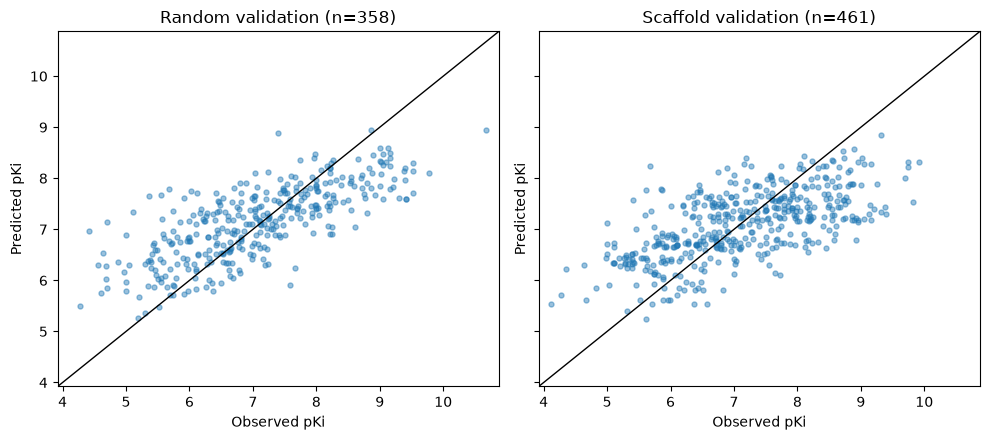

In [8]:
# Use validation points only and share limits between the two protocol panels.
validation_only = prediction_export.loc[prediction_export["subset"].eq("validation")]
lower = float(min(validation_only["observed_pki"].min(), validation_only["predicted_pki"].min()) - 0.2)
upper = float(max(validation_only["observed_pki"].max(), validation_only["predicted_pki"].max()) + 0.2)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
# Draw one point per structure and a perfect-prediction reference line.
for axis, strategy in zip(axes, XGBOOST_NAMES):
    rows = validation_only.loc[validation_only["split_strategy"].eq(strategy)]
    axis.scatter(rows["observed_pki"], rows["predicted_pki"], s=13, alpha=0.45)
    axis.plot([lower, upper], [lower, upper], color="black", linewidth=1)
    axis.set(xlim=(lower, upper), ylim=(lower, upper),
             title=f"{strategy.capitalize()} validation (n={len(rows):,})",
             xlabel="Observed pKi", ylabel="Predicted pKi")
fig.tight_layout()
plt.show()

## 8. Plot error against training similarity

Use the saved nearest-training similarities, with the same 0.80 reference line used by the forest notebook. This is descriptive analysis, not a tuning criterion.


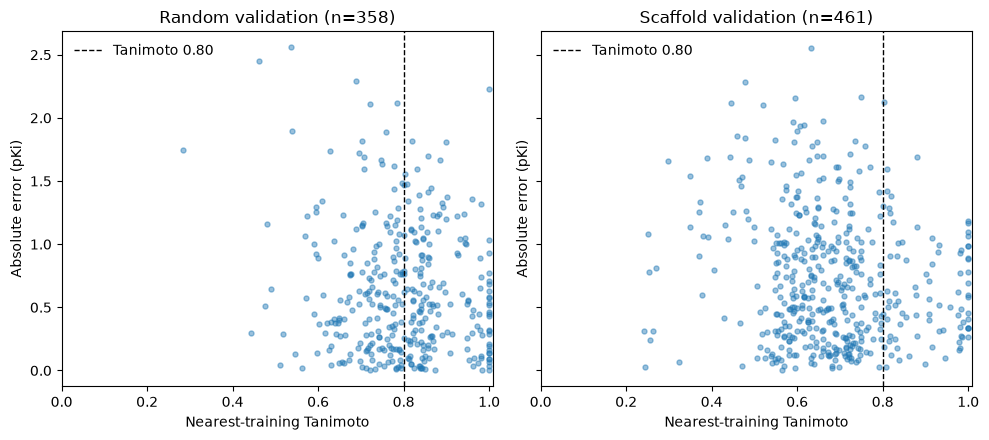

In [9]:
# Use the existing nearest-training values; no similarities are recomputed.
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for axis, strategy in zip(axes, XGBOOST_NAMES):
    rows = validation_only.loc[validation_only["split_strategy"].eq(strategy)]
    axis.scatter(rows["maximum_tanimoto"], rows["absolute_error"], s=13, alpha=0.45)
    # The dashed line marks the cutoff fixed in the modeling manifest.
    axis.axvline(cutoff, color="black", linestyle="--", linewidth=1, label="Tanimoto 0.80")
    axis.set(xlim=(0, 1.01), title=f"{strategy.capitalize()} validation (n={len(rows):,})",
             xlabel="Nearest-training Tanimoto", ylabel="Absolute error (pKi)")
    axis.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

## 9. Save this XGBoost baseline candidate

A temporary candidate holds the fitted baseline boosters, training summary, predictions, metrics, and similarity subgroups. Its completion manifest follows readback verification. After tuning also verifies, the complete candidate replaces the accepted `files/` and summary together. Compressed models retain their exact fitted state.


In [10]:
# Keep the accepted baseline and tuning available while a replacement is fitted.
# A temporary candidate becomes the accepted files/ only after both stages verify.
from xgboost_artifacts import new_xgboost_candidate, publish_xgboost
from forest_diagnostics import save_cliffs
xgb_candidate = new_xgboost_candidate(project_root)
xgb_folder = xgb_candidate / "baseline"
models_path = xgb_folder / "models.joblib.gz"
training_path = xgb_folder / "training_summary.csv"
prediction_path = xgb_folder / "predictions.csv"
metrics_path = xgb_folder / "metrics.csv"
subgroups_path = xgb_folder / "validation_subgroups.csv"
xgb_manifest_path = xgb_folder / "manifest.json"

joblib.dump(boosters, models_path, compress=("gzip", 3))
training_summary.to_csv(training_path, index=False)
prediction_export.to_csv(prediction_path, index=False)
metrics.to_csv(metrics_path, index=False)
subgroups.to_csv(subgroups_path, index=False)
print(f"Saved two boosters and four reports to {xgb_folder.relative_to(project_root).as_posix()}")
print("The run remains incomplete until its saved files are independently checked.")


Saved two boosters and four reports to provenance/models/xgboost/.pending-qx2jmvw7/baseline
The run remains incomplete until its saved files are independently checked.


## 10. Verify saved models and reports

Reload every exported report, recompute prediction arithmetic and metrics, confirm the saved models' fitted state, compare their predictions, verify source hashes, and exclude the reserved test structures.


In [11]:
# Read all output columns as text before controlled numeric conversion.
saved_predictions = pd.read_csv(prediction_path, dtype=str, keep_default_na=False)
saved_metrics = pd.read_csv(metrics_path, dtype=str, keep_default_na=False)
saved_subgroups = pd.read_csv(subgroups_path, dtype=str, keep_default_na=False)
assert list(saved_predictions.columns) == list(prediction_export.columns)
assert list(saved_metrics.columns) == list(metrics.columns)
assert list(saved_subgroups.columns) == list(subgroups.columns)
key_columns = ["split_strategy", "subset", "rdkit_smiles"]
assert not saved_predictions.duplicated(key_columns).any()
assert set(saved_predictions["split_strategy"]) == set(XGBOOST_NAMES)
assert set(saved_predictions["subset"]) == {"train", "validation"}
assert len(saved_predictions) == len(prediction_export)
target_by_key = dict(zip(structure_keys, y))
for strategy in XGBOOST_NAMES:
    for subset in ("train", "validation"):
        rows = saved_predictions.loc[
            saved_predictions["split_strategy"].eq(strategy) & saved_predictions["subset"].eq(subset)
        ]
        assert set(rows["rdkit_smiles"]) == set(structure_keys[split_indices[strategy][subset]])
        assert set(rows["rdkit_smiles"]).isdisjoint(structure_keys[split_indices[strategy]["test"]])
numeric_fields = ("observed_pki", "predicted_pki", "residual", "absolute_error", "squared_error")
for field in numeric_fields:
    saved_predictions[field] = pd.to_numeric(saved_predictions[field], errors="raise")
    assert np.isfinite(saved_predictions[field]).all(), f"Nonfinite saved prediction field: {field}"
# Reconnect observed targets to the verified NPZ keys instead of trusting CSV alone.
expected_observed = saved_predictions["rdkit_smiles"].map(target_by_key).to_numpy()
np.testing.assert_allclose(saved_predictions["observed_pki"], expected_observed, rtol=0, atol=1e-12)
rebuilt_residual = saved_predictions["predicted_pki"] - saved_predictions["observed_pki"]
np.testing.assert_allclose(saved_predictions["residual"], rebuilt_residual, rtol=0, atol=1e-12)
np.testing.assert_allclose(saved_predictions["absolute_error"], np.abs(rebuilt_residual), rtol=0, atol=1e-12)
np.testing.assert_allclose(saved_predictions["squared_error"], rebuilt_residual ** 2, rtol=0, atol=1e-12)
assert set(saved_predictions["exact_training_fingerprint_match"]) <= {"", "True", "False"}
saved_validation = saved_predictions.loc[saved_predictions["subset"].eq("validation")].copy()
saved_training = saved_predictions.loc[saved_predictions["subset"].eq("train")].copy()
assert saved_training["nearest_training_rdkit_smiles"].eq("").all()
assert saved_training["maximum_tanimoto"].eq("").all()
assert saved_training["exact_training_fingerprint_match"].eq("").all()
assert saved_validation["exact_training_fingerprint_match"].isin(["True", "False"]).all()
saved_validation["maximum_tanimoto"] = pd.to_numeric(saved_validation["maximum_tanimoto"], errors="raise")
assert saved_validation["maximum_tanimoto"].between(0, 1).all()
assert set(zip(saved_validation["split_strategy"], saved_validation["subset"], saved_validation["rdkit_smiles"])) == set(
    zip(validation_neighbors["split_strategy"], validation_neighbors["subset"], validation_neighbors["rdkit_smiles"])
)
audited_neighbor = validation_neighbors.set_index(key_columns)
for row in saved_validation.to_dict("records"):
    audit_row = audited_neighbor.loc[(row["split_strategy"], row["subset"], row["rdkit_smiles"])]
    assert row["nearest_training_rdkit_smiles"] == audit_row["nearest_training_rdkit_smiles"]
    assert np.isclose(row["maximum_tanimoto"], audit_row["maximum_tanimoto"], rtol=0, atol=1e-12)
    assert (row["exact_training_fingerprint_match"] == "True") == audit_row["exact_training_fingerprint_match"]

# Recompute each metric from the CSV rather than comparing only the number of rows.
assert len(saved_metrics) == 4
assert not saved_metrics.duplicated(["split_strategy", "subset"]).any()
for row in saved_metrics.to_dict("records"):
    strategy, subset = row["split_strategy"], row["subset"]
    selected = saved_predictions.loc[
        saved_predictions["split_strategy"].eq(strategy) & saved_predictions["subset"].eq(subset)
    ]
    assert int(row["n_structures"]) == len(selected)
    errors = selected["predicted_pki"].to_numpy() - selected["observed_pki"].to_numpy()
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    assert np.isclose(float(row["mae_pki"]), mae, rtol=0, atol=1e-12)
    assert np.isclose(float(row["rmse_pki"]), rmse, rtol=0, atol=1e-12)
    observed = selected["observed_pki"].to_numpy()
    if len(selected) >= 2 and np.max(observed) > np.min(observed):
        total = float(np.sum((observed - np.mean(observed)) ** 2))
        expected_r2 = 1 - float(np.sum(errors ** 2)) / total
        assert row["r2_status"] == "defined"
        assert np.isclose(float(row["r2"]), expected_r2, rtol=0, atol=1e-12)
    else:
        assert row["r2_status"] == "undefined_small_or_constant_target" and row["r2"] == ""

# The two subgroup partitions are checked independently, including possible empty categories.
assert len(saved_subgroups) == 8
assert not saved_subgroups.duplicated(["split_strategy", "grouping", "group"]).any()
for strategy in XGBOOST_NAMES:
    rows = saved_validation.loc[saved_validation["split_strategy"].eq(strategy)]
    exact = rows["exact_training_fingerprint_match"].eq("True")
    partition_masks = {
        ("exact_training_fingerprint", "exact_match"): exact,
        ("exact_training_fingerprint", "no_exact_match"): ~exact,
        ("nearest_training_tanimoto_0.80", "below_0.80"): rows["maximum_tanimoto"].lt(cutoff),
        ("nearest_training_tanimoto_0.80", "at_least_0.80"): rows["maximum_tanimoto"].ge(cutoff),
    }
    for (grouping, group), mask in partition_masks.items():
        result = saved_subgroups.loc[
            saved_subgroups["split_strategy"].eq(strategy)
            & saved_subgroups["grouping"].eq(grouping)
            & saved_subgroups["group"].eq(group)
        ]
        assert len(result) == 1
        result = result.iloc[0]
        selected = rows.loc[mask]
        assert int(result["n_structures"]) == len(selected)
        if len(selected):
            errors = selected["predicted_pki"].to_numpy() - selected["observed_pki"].to_numpy()
            assert np.isclose(float(result["mae_pki"]), np.mean(np.abs(errors)), rtol=0, atol=1e-12)
            assert np.isclose(float(result["rmse_pki"]), np.sqrt(np.mean(errors ** 2)), rtol=0, atol=1e-12)
            observed = selected["observed_pki"].to_numpy()
            if len(selected) >= 2 and np.max(observed) > np.min(observed):
                expected_r2 = 1 - np.sum(errors ** 2) / np.sum((observed - np.mean(observed)) ** 2)
                assert result["r2_status"] == "defined"
                assert np.isclose(float(result["r2"]), expected_r2, rtol=0, atol=1e-12)
            else:
                assert result["r2_status"] == "undefined_small_or_constant_target" and result["r2"] == ""
        else:
            assert result["mae_pki"] == result["rmse_pki"] == result["r2"] == ""
            assert result["r2_status"] == "undefined_empty"

# Reload only this run's model artifact and compare its fitted state with the live models.
loaded_boosters = joblib.load(models_path)
saved_training_summary = pd.read_csv(training_path)
assert set(loaded_boosters) == set(XGBOOST_NAMES.values())
assert len(saved_training_summary) == len(XGBOOST_NAMES)
assert not saved_training_summary.duplicated(["split_strategy", "model"]).any()
for strategy, model_name in XGBOOST_NAMES.items():
    loaded = loaded_boosters[model_name]
    assert isinstance(loaded, XGBRegressor)
    assert json_safe_parameters(loaded) == json_safe_parameters(boosters[model_name])
    assert loaded.n_features_in_ == feature_width
    assert loaded.get_booster().num_boosted_rounds() == xgb_parameters["n_estimators"]
    np.testing.assert_allclose(
        loaded.predict(X[training_slices[strategy]]),
        boosters[model_name].predict(X[training_slices[strategy]]), rtol=0, atol=1e-12,
    )
    row = saved_training_summary.loc[saved_training_summary["split_strategy"].eq(strategy)].iloc[0]
    assert row["model"] == model_name
    assert int(row["training_structures"]) == len(split_indices[strategy]["train"])
    assert int(row["features"]) == feature_width
    assert int(row["boosting_rounds"]) == xgb_parameters["n_estimators"]
    assert np.isfinite(float(row["fit_seconds"]))

assert sha256_file(prep_manifest_path) == source_manifest_hash, "Preparation manifest changed during XGBoost modeling."
for filename, path in artifact_paths.items():
    relative_name = (prep_folder_rel / filename).as_posix()
    assert sha256_file(path) == prep_manifest["artifact_sha256"][relative_name], (
        f"Preparation artifact changed during XGBoost modeling: {filename}"
    )
# Write the completion record only after every independent readback check passes.
xgb_manifest = {
    "run_started_at_utc": run_started_at_utc,
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "notebook": "notebooks/06_xgboost.ipynb",
    "stage": "xgboost_training_and_evaluation",
    "output_folder": xgb_folder.relative_to(project_root).as_posix(),
    "source_preparation_manifest": PREP_MANIFEST_REL.as_posix(),
    "source_preparation_manifest_sha256": source_manifest_hash,
    "source_artifact_sha256": {
        (prep_folder_rel / filename).as_posix(): prep_manifest["artifact_sha256"][
            (prep_folder_rel / filename).as_posix()
        ] for filename in required_filenames
    },
    "xgboost_names": XGBOOST_NAMES,
    "xgb_parameters": {strategy: json_safe_parameters(boosters[name]) for strategy, name in XGBOOST_NAMES.items()},
    "training_summary": training_summary.to_dict("records"),
    "counts": {
        "fitted_boosters": len(loaded_boosters),
        "predictions": len(saved_predictions),
        "overall_metric_rows": len(saved_metrics),
        "subgroup_rows": len(saved_subgroups),
        "subsets": {strategy: {
            subset: len(split_indices[strategy][subset]) for subset in SUBSETS
        } for strategy in XGBOOST_NAMES},
    },
    "metric_definitions": {
        "residual": "predicted_pki - observed_pki",
        "mae_pki": "mean absolute residual in pKi units",
        "rmse_pki": "square root of mean squared residual in pKi units",
        "r2": "1 - sum(squared residual) / sum((observed - evaluated-subset mean)^2); undefined if n<2 or target constant",
    },
    "subgroup_definitions": {
        "exact_training_fingerprint": ["exact_match", "no_exact_match"],
        "nearest_training_tanimoto_0.80": ["below_0.80", "at_least_0.80"],
        "similarity_cutoff": cutoff,
        "source": "saved validation rows in heldout_training_neighbors.csv",
    },
    "model_storage": {"format": "joblib gzip", "compression_level": 3},
    "output_sha256": {
        path.relative_to(project_root).as_posix(): sha256_file(path)
        for path in (models_path, training_path, prediction_path, metrics_path, subgroups_path)
    },
    "verification": {
        "input_hashes": True, "saved_models_and_training_state": True, "prediction_keys_and_arithmetic": True,
        "overall_metrics_recomputed": True, "subgroups_recomputed": True,
        "test_excluded": True,
    },
    "fitting_performed": True,
    "tuning_performed": False,
    "test_predictions_performed": False,
    "test_evaluation_performed": False,
    "software_versions": {**installed_versions, "matplotlib": matplotlib.__version__},
}
assert not xgb_manifest_path.exists()
with xgb_manifest_path.open("w", encoding="utf-8") as stream:
    json.dump(xgb_manifest, stream, indent=2)
print(f"Verified two fitted boosters, {len(saved_predictions):,} prediction rows, four metric rows, and eight subgroup rows.")
print(f"Completed XGBoost run: {xgb_folder.relative_to(project_root).as_posix()}")

Verified two fitted boosters, 6,457 prediction rows, four metric rows, and eight subgroup rows.
Completed XGBoost run: provenance/models/xgboost/.pending-qx2jmvw7/baseline


## 11. Tune XGBoost using training-only cross-validation

Use five folds inside each protocol's training subset. The random protocol uses shuffled KFold; the scaffold protocol uses GroupKFold to keep scaffold groups together within each fold. Choose parameters by the lowest mean fold MAE, refit the winner on all original training rows, then compare it with the baseline on outer validation. Outer validation and test rows never select a candidate. This is the best result within the declared eight-combination grid, not a claim about a global optimum.

The saved random split can place identical fingerprints across folds. Scaffold grouping reduces one source of similarity leakage but does not guarantee unique fingerprints across scaffold groups. The prepared audits document those limits.

XGBoost's [scikit-learn API](https://xgboost.readthedocs.io/en/stable/python/python_api.html) and [parameter tuning guidance](https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html) describe the estimator and thread settings used here.


In [12]:
from sklearn.model_selection import GridSearchCV, KFold, GroupKFold, ParameterGrid

# Freeze the search design before fitting candidates or inspecting their validation scores.
tuning_started_at_utc = datetime.now(timezone.utc).isoformat()
tuning_protocols = ("random", "scaffold")
tuning_n_folds = 5
tuning_cv_splits = {}
tuning_fold_rows = []
for protocol in tuning_protocols:
    train_indices = split_indices[protocol]["train"]
    train_keys = structure_keys[train_indices]
    scaffold_by_key = assignments.loc[
        assignments["split_strategy"].eq(protocol)
    ].set_index("rdkit_smiles")["scaffold"]
    train_groups = scaffold_by_key.loc[train_keys].to_numpy()
    # These indices address only the training array; outer validation/test never enter CV.
    if protocol == "random":
        splitter = KFold(n_splits=tuning_n_folds, shuffle=True, random_state=42)
        folds = list(splitter.split(train_indices))
    else:
        splitter = GroupKFold(n_splits=tuning_n_folds)
        folds = list(splitter.split(train_indices, groups=train_groups))
    heldout_counts = np.zeros(len(train_indices), dtype=int)
    for fold_number, (fit_local, valid_local) in enumerate(folds, start=1):
        assert set(fit_local).isdisjoint(valid_local)
        assert set(fit_local) | set(valid_local) == set(range(len(train_indices)))
        if protocol == "scaffold":
            assert set(train_groups[fit_local]).isdisjoint(train_groups[valid_local])
        heldout_counts[valid_local] += 1
        for local_index in valid_local:
            tuning_fold_rows.append({
                "split_strategy": protocol, "rdkit_smiles": train_keys[local_index],
                "scaffold": train_groups[local_index], "cv_validation_fold": fold_number,
            })
    assert np.all(heldout_counts == 1)
    tuning_cv_splits[protocol] = folds

tuning_folds = pd.DataFrame(tuning_fold_rows)
# Eight declared combinations include the fixed baseline. Search only three
# important boosting controls so this first comparison remains bounded.
tuning_grid = {
    "max_depth": [3, 4],
    "learning_rate": [0.05, 0.10],
    "n_estimators": [150, 250],
}
tuning_estimator = XGBRegressor(**xgb_parameters)
tuning_baseline_manifest_hash = sha256_file(xgb_manifest_path)
print(f"Candidates per protocol: {len(list(ParameterGrid(tuning_grid)))}; CV folds: {tuning_n_folds}")

Candidates per protocol: 8; CV folds: 5


### Run the declared search

The search evaluates every candidate on the saved training folds and refits the winner. Its fold scores are internal CV validation scores, not results on the protocol's reserved test set.


In [13]:
# Search candidates sequentially; each booster may use four CPU threads.
# Negative MAE follows sklearn's larger-is-better convention; reports use positive MAE.
tuning_models = {}
tuning_searches = {}
tuning_result_rows = []
tuning_selection = {}
for protocol in tuning_protocols:
    train_indices = split_indices[protocol]["train"]
    search = GridSearchCV(
        tuning_estimator, tuning_grid, scoring="neg_mean_absolute_error",
        cv=tuning_cv_splits[protocol], refit=True, n_jobs=1,
        error_score="raise", return_train_score=False,
    )
    started = perf_counter()
    search.fit(X[train_indices], y[train_indices])
    elapsed = perf_counter() - started
    # refit=True fits the CV winner on all supplied training rows, with no outer holdout.
    tuning_models[protocol] = search.best_estimator_
    tuning_searches[protocol] = search
    tuning_selection[protocol] = {
        "best_candidate_index": int(search.best_index_),
        "best_parameters": search.best_params_,
        "best_mean_cv_mae_pki": float(-search.best_score_),
        "effective_parameters": json_safe_parameters(search.best_estimator_),
        "training_structures": int(len(train_indices)), "search_seconds": elapsed,
        "refit_seconds": float(search.refit_time_),
    }
    for candidate_index, parameters in enumerate(search.cv_results_["params"]):
        result = {
            "split_strategy": protocol, "candidate_index": candidate_index,
            "parameters_json": json.dumps(parameters, sort_keys=True),
            "mean_cv_mae_pki": float(-search.cv_results_["mean_test_score"][candidate_index]),
            "std_cv_mae_pki": float(search.cv_results_["std_test_score"][candidate_index]),
            "rank": int(search.cv_results_["rank_test_score"][candidate_index]),
            "selected": candidate_index == search.best_index_,
        }
        # sklearn calls its internal held-out folds 'test'; these are training-only CV folds.
        for fold in range(tuning_n_folds):
            result[f"fold_{fold + 1}_validation_mae_pki"] = float(
                -search.cv_results_[f"split{fold}_test_score"][candidate_index]
            )
        tuning_result_rows.append(result)
    print(f"{protocol:<10} | best CV MAE {(-search.best_score_):.4f} | {elapsed:.1f} seconds")
    print(f"Selected parameters: {search.best_params_}")
tuning_results = pd.DataFrame(tuning_result_rows)

random     | best CV MAE 0.6032 | 13.0 seconds
Selected parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 250}


scaffold   | best CV MAE 0.6737 | 12.9 seconds
Selected parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 250}


### Compare baseline and selected-model predictions

Show training and outer-validation metrics for both. CV selects settings; outer validation describes how those settings transfer to its held-out molecules. Keep the selected model even if outer validation does not improve.


In [14]:
# Candidate selection is finished before predicting outer validation structures.
tuning_prediction_rows = []
tuning_metric_rows = []
for protocol in tuning_protocols:
    for subset in ("train", "validation"):
        indices = split_indices[protocol][subset]
        predicted = tuning_models[protocol].predict(X[indices])
        observed = y[indices]
        assert np.isfinite(predicted).all()
        for key, actual, estimate in zip(structure_keys[indices], observed, predicted):
            residual = float(estimate - actual)
            tuning_prediction_rows.append({
                "split_strategy": protocol, "subset": subset, "rdkit_smiles": key,
                "observed_pki": float(actual), "predicted_pki": float(estimate),
                "residual": residual, "absolute_error": abs(residual),
                "squared_error": residual ** 2,
            })
        r2_defined = len(observed) >= 2 and np.max(observed) > np.min(observed)
        tuning_metric_rows.append({
            "split_strategy": protocol, "subset": subset, "n_structures": len(indices),
            "mae_pki": float(mean_absolute_error(observed, predicted)),
            "rmse_pki": float(np.sqrt(mean_squared_error(observed, predicted))),
            "r2": float(r2_score(observed, predicted)) if r2_defined else np.nan,
            "r2_status": "defined" if r2_defined else "undefined_small_or_constant_target",
        })
tuning_predictions = pd.DataFrame(tuning_prediction_rows)
tuning_metrics = pd.DataFrame(tuning_metric_rows)

# Keep every baseline in the comparison, even when search does not improve validation.
tuning_baseline_metrics = metrics.copy()
tuning_baseline_metrics["model_variant"] = "baseline"
tuning_selected_metrics = tuning_metrics.assign(model_variant="cv_selected")
tuning_comparison = pd.concat([tuning_baseline_metrics, tuning_selected_metrics], ignore_index=True)
# Print the four train/validation pairs in a stable order so the generalization gap is visible.
print(f"{'Protocol':<10} | {'Variant':<12} | {'Subset':<10} | {'N':>5} | {'MAE':>8} | {'RMSE':>8} | {'R²':>8}")
for protocol in tuning_protocols:
    for variant in ("baseline", "cv_selected"):
        for subset in ("train", "validation"):
            selected = tuning_comparison.loc[
                tuning_comparison["split_strategy"].eq(protocol)
                & tuning_comparison["model_variant"].eq(variant)
                & tuning_comparison["subset"].eq(subset)
            ]
            assert len(selected) == 1
            row = selected.iloc[0]
            r2_text = f"{row['r2']:.4f}" if row["r2_status"] == "defined" else "undefined"
            print(f"{protocol:<10} | {variant:<12} | {subset:<10} | {row['n_structures']:>5,} | "
                  f"{row['mae_pki']:>8.4f} | {row['rmse_pki']:>8.4f} | {r2_text:>8}")
print("CV selected the parameters. Outer validation is a comparison; reserved test remains unused.")
print(f"\n{'Protocol':<10} | {'Observed':>9} | {'Predicted':>9} | {'Abs. error':>10}")
for row in tuning_predictions.loc[tuning_predictions["subset"].eq("validation")].groupby("split_strategy").head(2).itertuples():
    print(f"{row.split_strategy:<10} | {row.observed_pki:>9.4f} | {row.predicted_pki:>9.4f} | {row.absolute_error:>10.4f}")

Protocol   | Variant      | Subset     |     N |      MAE |     RMSE |       R²
random     | baseline     | train      | 2,860 |   0.5379 |   0.6674 |   0.6637
random     | baseline     | validation |   358 |   0.6356 |   0.8128 |   0.5320
random     | cv_selected  | train      | 2,860 |   0.4518 |   0.5640 |   0.7599
random     | cv_selected  | validation |   358 |   0.6059 |   0.7735 |   0.5762
scaffold   | baseline     | train      | 2,778 |   0.5170 |   0.6452 |   0.6865
scaffold   | baseline     | validation |   461 |   0.7230 |   0.8851 |   0.4025
scaffold   | cv_selected  | train      | 2,778 |   0.4358 |   0.5471 |   0.7746
scaffold   | cv_selected  | validation |   461 |   0.7081 |   0.8762 |   0.4143
CV selected the parameters. Outer validation is a comparison; reserved test remains unused.

Protocol   |  Observed | Predicted | Abs. error
random     |    5.7447 |    5.8975 |     0.1528
random     |    7.6198 |    7.4024 |     0.2174
scaffold   |    6.3757 |    7.3936 |     1.

### Compare validation subgroups after tuning

Join selected-model predictions to the same saved nearest-training neighbors used for the baseline. Report both fingerprint-match and 0.80 Tanimoto partitions for each protocol. The structure counts must remain the same; only prediction errors can change. These subgroups describe the outer validation set and do not choose search parameters.


In [15]:
# The three-key join reuses each protocol's fixed validation-neighbor audit.
tuned_validation_predictions = tuning_predictions.loc[
    tuning_predictions["subset"].eq("validation")
].merge(
    validation_neighbors[[
        "split_strategy", "subset", "rdkit_smiles", "nearest_training_rdkit_smiles",
        "maximum_tanimoto", "exact_training_fingerprint_match",
    ]],
    on=["split_strategy", "subset", "rdkit_smiles"], how="left",
    validate="one_to_one", indicator=True,
)
assert tuned_validation_predictions["_merge"].eq("both").all()
tuned_validation_predictions = tuned_validation_predictions.drop(columns="_merge")
assert len(tuned_validation_predictions) == len(validation_predictions)

# Recompute the same four categories for each protocol using selected-model errors.
tuning_subgroup_rows = []
for strategy in XGBOOST_NAMES:
    rows = tuned_validation_predictions.loc[
        tuned_validation_predictions["split_strategy"].eq(strategy)
    ]
    partitions = [
        ("exact_training_fingerprint", "exact_match", rows["exact_training_fingerprint_match"]),
        ("exact_training_fingerprint", "no_exact_match", ~rows["exact_training_fingerprint_match"]),
        ("nearest_training_tanimoto_0.80", "below_0.80", rows["maximum_tanimoto"].lt(cutoff)),
        ("nearest_training_tanimoto_0.80", "at_least_0.80", rows["maximum_tanimoto"].ge(cutoff)),
    ]
    for grouping, group, mask in partitions:
        selected = rows.loc[mask]
        observed = selected["observed_pki"].to_numpy()
        predicted = selected["predicted_pki"].to_numpy()
        r2_defined = len(selected) >= 2 and np.max(observed) > np.min(observed) if len(selected) else False
        tuning_subgroup_rows.append({
            "split_strategy": strategy, "grouping": grouping, "group": group,
            "n_structures": len(selected),
            "mae_pki": float(mean_absolute_error(observed, predicted)) if len(selected) else np.nan,
            "rmse_pki": float(np.sqrt(mean_squared_error(observed, predicted))) if len(selected) else np.nan,
            "r2": float(r2_score(observed, predicted)) if r2_defined else np.nan,
            "r2_status": "defined" if r2_defined else (
                "undefined_empty" if not len(selected) else "undefined_small_or_constant_target"
            ),
        })
tuning_subgroups = pd.DataFrame(tuning_subgroup_rows, columns=subgroups.columns)

# Matching group sizes confirm that both models are compared on identical structures.
print(f"{'Protocol':<10} | {'Grouping':<31} | {'Category':<15} | {'N':>5} | {'Base MAE':>9} | {'Tuned MAE':>9} | {'Change':>8}")
for row in tuning_subgroups.itertuples(index=False):
    baseline = subgroups.loc[
        subgroups["split_strategy"].eq(row.split_strategy)
        & subgroups["grouping"].eq(row.grouping)
        & subgroups["group"].eq(row.group)
    ]
    assert len(baseline) == 1 and baseline.iloc[0]["n_structures"] == row.n_structures
    baseline_mae = baseline.iloc[0]["mae_pki"]
    base_text = f"{baseline_mae:.3f}" if row.n_structures else "undefined"
    tuned_text = f"{row.mae_pki:.3f}" if row.n_structures else "undefined"
    change_text = f"{row.mae_pki - baseline_mae:+.3f}" if row.n_structures else "undefined"
    print(f"{row.split_strategy:<10} | {row.grouping:<31} | {row.group:<15} | "
          f"{row.n_structures:>5,} | {base_text:>9} | {tuned_text:>9} | {change_text:>8}")
print("Change is selected MAE minus baseline MAE; smaller is better. Small groups are descriptive.")


Protocol   | Grouping                        | Category        |     N |  Base MAE | Tuned MAE |   Change
random     | exact_training_fingerprint      | exact_match     |    27 |     0.466 |     0.461 |   -0.005
random     | exact_training_fingerprint      | no_exact_match  |   331 |     0.649 |     0.618 |   -0.032
random     | nearest_training_tanimoto_0.80  | below_0.80      |   179 |     0.658 |     0.634 |   -0.024
random     | nearest_training_tanimoto_0.80  | at_least_0.80   |   179 |     0.613 |     0.578 |   -0.036
scaffold   | exact_training_fingerprint      | exact_match     |    18 |     0.724 |     0.676 |   -0.048
scaffold   | exact_training_fingerprint      | no_exact_match  |   443 |     0.723 |     0.709 |   -0.014
scaffold   | nearest_training_tanimoto_0.80  | below_0.80      |   375 |     0.740 |     0.728 |   -0.012
scaffold   | nearest_training_tanimoto_0.80  | at_least_0.80   |    86 |     0.648 |     0.622 |   -0.026
Change is selected MAE minus baseline MAE; sma

### Plot observed and predicted validation pKi after tuning

Compare the baseline and selected model for both protocols. Each panel uses the same axis limits, so changes in spread can be seen without a scale change. Only outer-validation structures appear here.


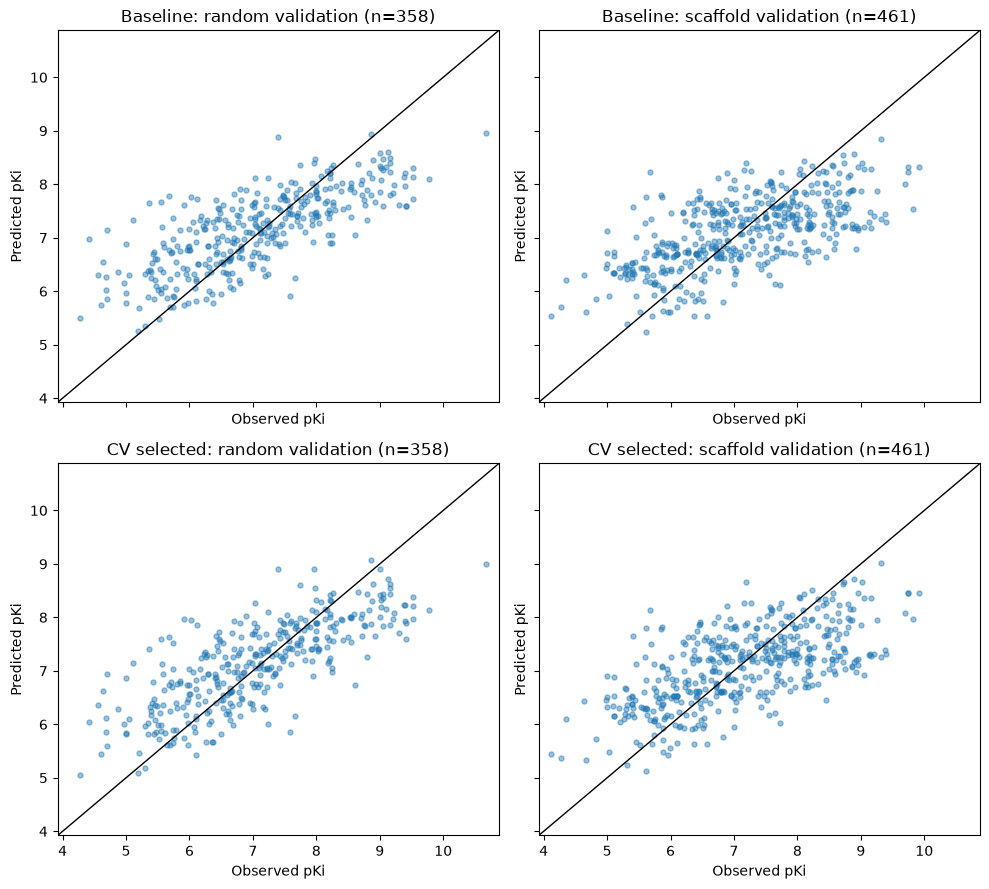

In [16]:
# Use one scale across all four panels for a direct visual comparison.
plot_lower = float(min(
    validation_predictions["observed_pki"].min(), validation_predictions["predicted_pki"].min(),
    tuned_validation_predictions["predicted_pki"].min(),
) - 0.2)
plot_upper = float(max(
    validation_predictions["observed_pki"].max(), validation_predictions["predicted_pki"].max(),
    tuned_validation_predictions["predicted_pki"].max(),
) + 0.2)
fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
for row_number, (variant, frame) in enumerate((
    ("Baseline", validation_predictions), ("CV selected", tuned_validation_predictions)
)):
    for column_number, strategy in enumerate(XGBOOST_NAMES):
        axis = axes[row_number, column_number]
        rows = frame.loc[frame["split_strategy"].eq(strategy)]
        axis.scatter(rows["observed_pki"], rows["predicted_pki"], s=13, alpha=0.45)
        axis.plot([plot_lower, plot_upper], [plot_lower, plot_upper], color="black", linewidth=1)
        axis.set(xlim=(plot_lower, plot_upper), ylim=(plot_lower, plot_upper),
                 title=f"{variant}: {strategy} validation (n={len(rows):,})",
                 xlabel="Observed pKi", ylabel="Predicted pKi")
fig.tight_layout()
plt.show()


### Plot validation error against training similarity after tuning

Place baseline and selected-model errors against the same saved nearest-training Tanimoto values. The dashed 0.80 line is the preparation diagnostic cutoff. A shared vertical scale lets the four panels show whether tuning changed errors across similarity levels.


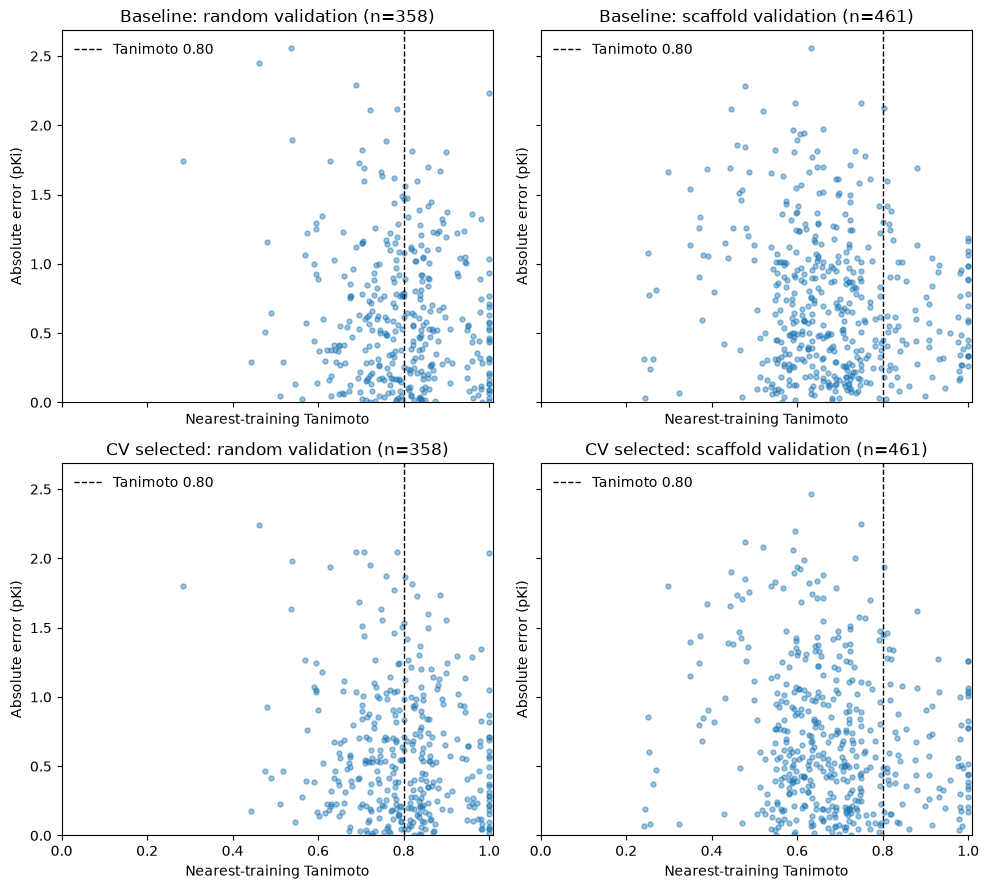

In [17]:
# Similarity belongs to the split and structure, so both model variants use the same x coordinates.
error_upper = 1.05 * float(max(
    validation_predictions["absolute_error"].max(),
    tuned_validation_predictions["absolute_error"].max(),
))
fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
for row_number, (variant, frame) in enumerate((
    ("Baseline", validation_predictions), ("CV selected", tuned_validation_predictions)
)):
    for column_number, strategy in enumerate(XGBOOST_NAMES):
        axis = axes[row_number, column_number]
        rows = frame.loc[frame["split_strategy"].eq(strategy)]
        axis.scatter(rows["maximum_tanimoto"], rows["absolute_error"], s=13, alpha=0.45)
        axis.axvline(cutoff, color="black", linestyle="--", linewidth=1, label="Tanimoto 0.80")
        axis.set(xlim=(0, 1.01), ylim=(0, error_upper),
                 title=f"{variant}: {strategy} validation (n={len(rows):,})",
                 xlabel="Nearest-training Tanimoto", ylabel="Absolute error (pKi)")
        axis.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


### Save the search and its provenance

The same temporary candidate receives a `tuning/` folder beside `baseline/`, with fold assignments, candidate scores, selected parameters, fitted models, predictions, metrics, similarity subgroups, and the baseline comparison. Its completion manifest is written after readback checks.


In [18]:
# Keep tuning beside its baseline within the same temporary experiment.
tuning_folder = xgb_candidate / "tuning"
tuning_folder.mkdir(exist_ok=False)
tuning_tables = {
    "cv_folds.csv": tuning_folds,
    "cv_results.csv": tuning_results,
    "predictions.csv": tuning_predictions,
    "metrics.csv": tuning_metrics,
    "validation_subgroups.csv": tuning_subgroups,
    "baseline_comparison.csv": tuning_comparison,
}
for filename, table in tuning_tables.items():
    table.to_csv(tuning_folder / filename, index=False)
joblib.dump(tuning_models, tuning_folder / "models.joblib.gz", compress=("gzip", 3))
with (tuning_folder / "best_parameters.json").open("w", encoding="utf-8") as stream:
    json.dump(tuning_selection, stream, indent=2)
print(f"Search artifacts: {tuning_folder.relative_to(project_root).as_posix()}")

Search artifacts: provenance/models/xgboost/.pending-qx2jmvw7/tuning


### Verify saved search artifacts

Check training-only fold membership, scaffold separation, selected candidate, model predictions, metric and subgroup arithmetic, source hashes, and test exclusion.


In [19]:
# Read the files back before marking the search complete.
for filename, original in tuning_tables.items():
    reloaded = pd.read_csv(tuning_folder / filename, keep_default_na=False)
    expected = original.fillna("")
    pd.testing.assert_frame_equal(reloaded, expected, check_dtype=False, rtol=1e-12, atol=1e-12)
checked_folds = pd.read_csv(tuning_folder / "cv_folds.csv", keep_default_na=False)
checked_results = pd.read_csv(tuning_folder / "cv_results.csv")
checked_predictions = pd.read_csv(tuning_folder / "predictions.csv")
checked_metrics = pd.read_csv(tuning_folder / "metrics.csv")
checked_models = joblib.load(tuning_folder / "models.joblib.gz")
with (tuning_folder / "best_parameters.json").open(encoding="utf-8") as stream:
    checked_selection = json.load(stream)
assert checked_selection == tuning_selection
assert set(checked_models) == set(tuning_protocols)
assert not checked_folds.duplicated(["split_strategy", "rdkit_smiles"]).any()
assert not checked_predictions.duplicated(["split_strategy", "subset", "rdkit_smiles"]).any()
assert set(checked_predictions["subset"]) == {"train", "validation"}

for protocol in tuning_protocols:
    train_indices = split_indices[protocol]["train"]
    fold_rows = checked_folds.loc[checked_folds["split_strategy"].eq(protocol)]
    assert set(fold_rows["rdkit_smiles"]) == set(structure_keys[train_indices])
    assert set(fold_rows["cv_validation_fold"]) == set(range(1, tuning_n_folds + 1))
    if protocol == "scaffold":
        assert fold_rows.groupby("scaffold")["cv_validation_fold"].nunique().eq(1).all()
    candidate_rows = checked_results.loc[checked_results["split_strategy"].eq(protocol)]
    assert len(candidate_rows) == len(list(ParameterGrid(tuning_grid)))
    fold_scores = candidate_rows[[f"fold_{fold}_validation_mae_pki" for fold in range(1, tuning_n_folds + 1)]].to_numpy()
    assert np.isfinite(fold_scores).all() and (fold_scores >= 0).all()
    np.testing.assert_allclose(candidate_rows["mean_cv_mae_pki"], fold_scores.mean(axis=1), atol=1e-12)
    np.testing.assert_allclose(candidate_rows["std_cv_mae_pki"], fold_scores.std(axis=1), atol=1e-12)
    selected = candidate_rows.loc[candidate_rows["selected"]]
    assert len(selected) == 1 and selected.iloc[0]["rank"] == 1
    assert selected.iloc[0]["candidate_index"] == checked_selection[protocol]["best_candidate_index"]
    assert np.isclose(selected.iloc[0]["mean_cv_mae_pki"], candidate_rows["mean_cv_mae_pki"].min(), atol=1e-12)
    assert json.loads(selected.iloc[0]["parameters_json"]) == checked_selection[protocol]["best_parameters"]
    assert json_safe_parameters(checked_models[protocol]) == json_safe_parameters(tuning_models[protocol])
    assert checked_models[protocol].n_features_in_ == feature_width
    for subset in ("train", "validation"):
        indices = split_indices[protocol][subset]
        rows = checked_predictions.loc[
            checked_predictions["split_strategy"].eq(protocol) & checked_predictions["subset"].eq(subset)
        ].set_index("rdkit_smiles")
        assert set(rows.index) == set(structure_keys[indices])
        assert set(rows.index).isdisjoint(structure_keys[split_indices[protocol]["test"]])
        rows = rows.loc[structure_keys[indices]]
        # Full readback predictions verify the serialized winner as well as CSV alignment.
        np.testing.assert_allclose(rows["predicted_pki"], checked_models[protocol].predict(X[indices]), rtol=0, atol=1e-10)
        np.testing.assert_allclose(rows["observed_pki"], y[indices], rtol=0, atol=1e-12)
        errors = rows["predicted_pki"].to_numpy() - y[indices]
        np.testing.assert_allclose(rows["residual"], errors, rtol=0, atol=1e-12)
        np.testing.assert_allclose(rows["absolute_error"], np.abs(errors), rtol=0, atol=1e-12)
        np.testing.assert_allclose(rows["squared_error"], errors ** 2, rtol=0, atol=1e-12)
        metric = checked_metrics.loc[
            checked_metrics["split_strategy"].eq(protocol) & checked_metrics["subset"].eq(subset)
        ].iloc[0]
        assert metric["n_structures"] == len(indices)
        np.testing.assert_allclose(metric["mae_pki"], np.abs(errors).mean(), atol=1e-12)
        np.testing.assert_allclose(metric["rmse_pki"], np.sqrt((errors ** 2).mean()), atol=1e-12)
        if metric["r2_status"] == "defined":
            expected_r2 = 1 - np.sum(errors ** 2) / np.sum((y[indices] - y[indices].mean()) ** 2)
            np.testing.assert_allclose(metric["r2"], expected_r2, atol=1e-12)

# Rejoin saved selected-model predictions to the frozen similarity audit and recalculate
# every reported subgroup. This checks group membership and error arithmetic after CSV readback.
checked_subgroups = pd.read_csv(tuning_folder / "validation_subgroups.csv", dtype=str, keep_default_na=False)
assert list(checked_subgroups.columns) == list(subgroups.columns)
assert len(checked_subgroups) == 8
assert not checked_subgroups.duplicated(["split_strategy", "grouping", "group"]).any()
checked_validation = checked_predictions.loc[
    checked_predictions["subset"].eq("validation")
].merge(
    validation_neighbors[[
        "split_strategy", "subset", "rdkit_smiles", "maximum_tanimoto",
        "exact_training_fingerprint_match",
    ]],
    on=["split_strategy", "subset", "rdkit_smiles"], how="left",
    validate="one_to_one", indicator=True,
)
assert checked_validation["_merge"].eq("both").all()
assert len(checked_validation) == len(validation_neighbors)
for strategy in XGBOOST_NAMES:
    rows = checked_validation.loc[checked_validation["split_strategy"].eq(strategy)]
    partitions = [
        ("exact_training_fingerprint", "exact_match", rows["exact_training_fingerprint_match"]),
        ("exact_training_fingerprint", "no_exact_match", ~rows["exact_training_fingerprint_match"]),
        ("nearest_training_tanimoto_0.80", "below_0.80", rows["maximum_tanimoto"].lt(cutoff)),
        ("nearest_training_tanimoto_0.80", "at_least_0.80", rows["maximum_tanimoto"].ge(cutoff)),
    ]
    for grouping, group, mask in partitions:
        result = checked_subgroups.loc[
            checked_subgroups["split_strategy"].eq(strategy)
            & checked_subgroups["grouping"].eq(grouping)
            & checked_subgroups["group"].eq(group)
        ]
        assert len(result) == 1
        result = result.iloc[0]
        selected = rows.loc[mask]
        assert int(result["n_structures"]) == len(selected)
        if len(selected):
            errors = selected["predicted_pki"].to_numpy() - selected["observed_pki"].to_numpy()
            assert np.isclose(float(result["mae_pki"]), np.mean(np.abs(errors)), rtol=0, atol=1e-12)
            assert np.isclose(float(result["rmse_pki"]), np.sqrt(np.mean(errors ** 2)), rtol=0, atol=1e-12)
            observed = selected["observed_pki"].to_numpy()
            if len(selected) >= 2 and np.max(observed) > np.min(observed):
                expected_r2 = 1 - np.sum(errors ** 2) / np.sum((observed - np.mean(observed)) ** 2)
                assert result["r2_status"] == "defined"
                assert np.isclose(float(result["r2"]), expected_r2, rtol=0, atol=1e-12)
            else:
                assert result["r2_status"] == "undefined_small_or_constant_target" and result["r2"] == ""
        else:
            assert result["mae_pki"] == result["rmse_pki"] == result["r2"] == ""
            assert result["r2_status"] == "undefined_empty"

# Link the completed search to frozen data and the completed baseline run.
assert sha256_file(prep_manifest_path) == source_manifest_hash
for filename, path in artifact_paths.items():
    assert sha256_file(path) == prep_manifest["artifact_sha256"][(prep_folder_rel / filename).as_posix()]
assert sha256_file(xgb_manifest_path) == tuning_baseline_manifest_hash
tuning_output_paths = [tuning_folder / filename for filename in tuning_tables]
tuning_output_paths += [tuning_folder / "models.joblib.gz", tuning_folder / "best_parameters.json"]
tuning_manifest = {
    "stage": 'xgboost_hyperparameter_search', "notebook": 'notebooks/06_xgboost.ipynb',
    "run_started_at_utc": tuning_started_at_utc,
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "output_folder": tuning_folder.relative_to(project_root).as_posix(),
    "source_preparation_manifest": PREP_MANIFEST_REL.as_posix(),
    "source_preparation_manifest_sha256": source_manifest_hash,
    "source_artifact_sha256": {
        path.relative_to(project_root).as_posix(): sha256_file(path) for path in artifact_paths.values()
    },
    "baseline_manifest": xgb_manifest_path.relative_to(project_root).as_posix(),
    "baseline_manifest_sha256": tuning_baseline_manifest_hash,
    "configuration": {
        "search": "GridSearchCV", "parameter_grid": tuning_grid,
        "scoring": "neg_mean_absolute_error", "refit": True, "search_n_jobs": 1,
        "folds": tuning_n_folds,
        "random_cv": {"method": "KFold", "shuffle": True, "random_state": 42},
        "scaffold_cv": {"method": "GroupKFold", "shuffle": False, "group": "saved_scaffold"},
        "selection_rule": "minimum unweighted mean fold MAE; first candidate breaks ties",
        "scope": "bounded first search; best within the declared grid",
    },
    "selection": tuning_selection,
    "counts": {"candidates_per_protocol": len(list(ParameterGrid(tuning_grid))),
               "selected_models": len(tuning_models), "prediction_rows": len(tuning_predictions),
               "subgroup_rows": len(tuning_subgroups)},
    "subgroup_definitions": xgb_manifest["subgroup_definitions"],
    "model_storage": {"format": "joblib gzip", "compression_level": 3},
    "output_sha256": {path.relative_to(project_root).as_posix(): sha256_file(path) for path in tuning_output_paths},
    "verification": {"input_hashes": True, "saved_tables_and_selection": True,
                     "training_only_cv_folds": True, "scaffold_cv_groups_disjoint": True,
                     "serialized_model_predictions": True, "metrics_recomputed": True,
                     "validation_subgroups_recomputed": True, "test_excluded": True},
    "fitting_performed": True, "tuning_performed": True,
    "outer_validation_used_for_search": False,
    "test_predictions_performed": False, "test_evaluation_performed": False,
    "software_versions": installed_versions,
}
with (tuning_folder / "manifest.json").open("x", encoding="utf-8") as stream:
    json.dump(tuning_manifest, stream, indent=2)
print("Verified training-only CV, saved models, predictions, metrics, similarity subgroups, and source hashes.")
print(f"Completed search: {tuning_folder.relative_to(project_root).as_posix()}")
# Freeze validation-only pairs directly from this preparation, using the same
# Tanimoto and pKi-gap thresholds as the other model summaries.
save_cliffs(project_root, xgb_candidate / "diagnostics", PREP_MANIFEST_REL,
            X, y, structure_keys, split_indices,
            stage="xgboost_report_diagnostics")
# Publish both variants and their summary together. A failed workbook save
# restores the previous complete result; it never leaves a half-updated pair.
xgb_files = publish_xgboost(project_root, xgb_candidate)
xgb_folder = xgb_files / "baseline"
tuning_folder = xgb_files / "tuning"
xgb_manifest_path = xgb_folder / "manifest.json"
print(f"Accepted XGBoost results: {xgb_files.relative_to(project_root)}")


Verified training-only CV, saved models, predictions, metrics, similarity subgroups, and source hashes.
Completed search: provenance/models/xgboost/.pending-qx2jmvw7/tuning


Accepted XGBoost results: provenance/models/xgboost/files


## Stopping point

This notebook owns the fixed XGBoost baselines and a completed training-only search for both protocols. The accepted run contains fitted models, all training and validation predictions, metrics, baseline and selected-model similarity subgroups, plots, full search scores, and provenance. The reserved test sets remain available for the final evaluation after model choices are settled.


## Refresh the project reference
After this stage passes its checks, update the model comparison and project file guide. The data provenance workbook is regenerated from the current data. Existing model results remain labeled with the dataset that produced them.


In [20]:
# Verify saved evidence and refresh Markdown references; preserve the presentation workbook.
from build_project_reference import build_reference
build_reference()


{
  "checksum_references": 105,
  "recomputed_metric_rows": 28,
  "active_notebooks": 10,
  "model_comparison_rows": 14,
  "current_pipeline": {
    "acquisition": "provenance/raw/chembl_cb2_20260922T165756862384Z/acquisition_manifest.json",
    "selection": "provenance/selection/chembl_cb2_20260922T165756862384Z/selection_manifest.json",
    "curation": "provenance/curation/manifest.json",
    "preparation": "provenance/preparation/manifest.json"
  },
  "reports_written": true,
  "presentation_workbook": "preserved unchanged"
}


{'checksum_references': 105,
 'recomputed_metric_rows': 28,
 'active_notebooks': 10,
 'model_comparison_rows': 14,
 'current_pipeline': {'acquisition': 'provenance/raw/chembl_cb2_20260922T165756862384Z/acquisition_manifest.json',
  'selection': 'provenance/selection/chembl_cb2_20260922T165756862384Z/selection_manifest.json',
  'curation': 'provenance/curation/manifest.json',
  'preparation': 'provenance/preparation/manifest.json'},
 'reports_written': True,
 'presentation_workbook': 'preserved unchanged'}